# Machine Learning

### Random Forest com dataset_treino

Notebook baseado no exemplo de aula, adaptado para o conjunto dataset_treino.csv.

In [5]:
import math
import random
import csv
import matplotlib.pyplot as plt
from collections import Counter


In [6]:
# Mapeamento de rótulos texto → número
LABEL_MAP = {
    'Tem jogo'         : 0,
    'Possibilidade_fim': 1,
    'Empate'           : 2,
    'Fim_O_Vence'      : 3,
    'Fim_X_Vence'      : 4
}
LABEL_NAMES = ['Tem jogo', 'Possibilidade_fim', 'Empate', 'Fim_O_Vence', 'Fim_X_Vence']
NOMES_CURTOS = ['Tem jogo', 'Poss. Fim', 'Empate', 'O Vence', 'X Vence']

def carrega_dataset(caminho):
    """Lê o CSV e retorna listas X (features) e y (rótulos numéricos)."""
    X_lista, y_lista = [], []
    with open(caminho) as f:
        for linha in csv.reader(f):
            X_lista.append([float(v) for v in linha[:9]])
            y_lista.append(LABEL_MAP[linha[9]])
    return X_lista, y_lista

X_treino, y_treino = carrega_dataset('/content/sample_data/dataset_treino.csv')
X_teste,  y_teste  = carrega_dataset('/content/sample_data/dataset_testes.csv')

print('=== Amostras por classe – Treino ===')
for i, nome in enumerate(LABEL_NAMES):
    print(f'  {nome}: {sum(1 for y in y_treino if y == i)}')

print(f'\nTotal treino : {len(X_treino)}')
print(f'Total teste  : {len(X_teste)}')
print(f'\nExemplo de entrada : {X_treino[0]}')
print(f'Rótulo correspondente: {LABEL_NAMES[y_treino[0]]}')


=== Amostras por classe – Treino ===
  Tem jogo: 180
  Possibilidade_fim: 180
  Empate: 166
  Fim_O_Vence: 180
  Fim_X_Vence: 180

Total treino : 886
Total teste  : 98

Exemplo de entrada : [1.0, 1.0, -1.0, -1.0, -1.0, 1.0, 1.0, -1.0, 1.0]
Rótulo correspondente: Empate


In [7]:
def gini(y_lista):
    """
    Calcula a impureza de Gini de uma lista de rótulos.
    Gini = 1 - soma(p_k^2) para cada classe k.
    Gini = 0 significa nó puro (todas as amostras da mesma classe).
    """
    n = len(y_lista)
    if n == 0:
        return 0.0
    contagem = Counter(y_lista)
    return 1.0 - sum((c / n) ** 2 for c in contagem.values())

# Exemplos de impureza de Gini
print('Gini de nó puro  (todos classe 0):', gini([0, 0, 0, 0]))
print('Gini perfeitamente misto (5 classes iguais):', round(gini([0,1,2,3,4]*4), 4))
print('Gini parcialmente misto :', round(gini([0,0,0,1,1,2]), 4))


Gini de nó puro  (todos classe 0): 0.0
Gini perfeitamente misto (5 classes iguais): 0.8
Gini parcialmente misto : 0.6111


In [8]:
def melhor_split(X, y, features_idx):
    """
    Encontra a melhor feature e limiar para dividir o nó.

    Parâmetros:
        X          – lista de amostras (features)
        y          – lista de rótulos
        features_idx – índices das features a considerar (subconjunto aleatório)

    Retorna:
        (melhor_feature, melhor_limiar)  ou  (None, None) se não houver ganho
    """
    melhor_ganho = -1
    melhor_feat  = None
    melhor_thr   = None
    gini_pai = gini(y)
    n = len(y)

    for f in features_idx:
        # Limiares candidatos: pontos médios entre valores únicos consecutivos
        valores   = sorted(set(x[f] for x in X))
        limiares  = [(valores[i] + valores[i+1]) / 2
                     for i in range(len(valores) - 1)]

        for thr in limiares:
            esq_y = [y[i] for i in range(n) if X[i][f] <= thr]
            dir_y = [y[i] for i in range(n) if X[i][f] >  thr]

            if not esq_y or not dir_y:
                continue  # divisão trivial, ignorar

            ganho = (gini_pai
                     - (len(esq_y) / n) * gini(esq_y)
                     - (len(dir_y) / n) * gini(dir_y))

            if ganho > melhor_ganho:
                melhor_ganho = ganho
                melhor_feat  = f
                melhor_thr   = thr

    return melhor_feat, melhor_thr

# Teste rápido
feat, thr = melhor_split(X_treino[:50], y_treino[:50],
                         features_idx=[0,1,2,3,4,5,6,7,8])
print(f'Melhor split (50 amostras): feature={feat}, limiar={thr}')
print(f'  → posição do tabuleiro {feat} com limiar {thr}')


Melhor split (50 amostras): feature=5, limiar=-0.5
  → posição do tabuleiro 5 com limiar -0.5


In [9]:
def constroi_arvore(X, y, prof_max, min_amostras, n_features, prof=0):
    """
    Constrói recursivamente uma árvore de decisão.

    Parâmetros:
        X           – lista de amostras
        y           – lista de rótulos
        prof_max    – profundidade máxima da árvore
        min_amostras– mínimo de amostras para tentar dividir
        n_features  – nº de features avaliadas em cada nó (aleatoriedade RF)
        prof        – profundidade atual (uso interno)

    Retorna:
        Nó folha (int = classe) ou nó interno (dict com feat, thr, esq, dir)
    """
    # ── Critérios de parada ────────────────────────────────
    if len(y) <= min_amostras or prof >= prof_max or len(set(y)) == 1:
        return Counter(y).most_common(1)[0][0]   # folha: classe majoritária

    # ── Selecionar subconjunto aleatório de features ────────
    n_total_feats = len(X[0])
    features_idx  = random.sample(range(n_total_feats),
                                  k=min(n_features, n_total_feats))

    # ── Encontrar melhor divisão ────────────────────────────
    feat, thr = melhor_split(X, y, features_idx)
    if feat is None:
        return Counter(y).most_common(1)[0][0]   # sem ganho possível → folha

    # ── Particionar amostras ────────────────────────────────
    esq_X = [X[i] for i in range(len(X)) if X[i][feat] <= thr]
    esq_y = [y[i] for i in range(len(y)) if X[i][feat] <= thr]
    dir_X = [X[i] for i in range(len(X)) if X[i][feat] >  thr]
    dir_y = [y[i] for i in range(len(y)) if X[i][feat] >  thr]

    # ── Recursão ────────────────────────────────────────────
    return {
        'feat': feat,
        'thr' : thr,
        'esq' : constroi_arvore(esq_X, esq_y, prof_max, min_amostras, n_features, prof+1),
        'dir' : constroi_arvore(dir_X, dir_y, prof_max, min_amostras, n_features, prof+1)
    }

print('Função constroi_arvore definida com sucesso.')


Função constroi_arvore definida com sucesso.


In [10]:
def prediz_arvore(no, x):
    """
    Classifica a amostra x percorrendo a árvore recursivamente.

    Parâmetros:
        no – nó atual (int se folha, dict se nó interno)
        x  – vetor de features da amostra

    Retorna:
        Classe predita (int)
    """
    if not isinstance(no, dict):
        return no   # folha: retorna a classe

    if x[no['feat']] <= no['thr']:
        return prediz_arvore(no['esq'], x)
    else:
        return prediz_arvore(no['dir'], x)

# Teste rápido com uma árvore de profundidade 3
random.seed(42)
arvore_teste = constroi_arvore(X_treino, y_treino,
                               prof_max=3, min_amostras=2, n_features=3)
pred_ex = prediz_arvore(arvore_teste, X_treino[0])
print(f'Amostra: {X_treino[0]}')
print(f'Real   : {LABEL_NAMES[y_treino[0]]}')
print(f'Predito: {LABEL_NAMES[pred_ex]}')


Amostra: [1.0, 1.0, -1.0, -1.0, -1.0, 1.0, 1.0, -1.0, 1.0]
Real   : Empate
Predito: Fim_X_Vence


In [11]:
def bootstrap(X, y):
    """
    Gera uma amostra bootstrap (com reposição) do mesmo tamanho do dataset.

    Retorna:
        (X_boot, y_boot) – subconjunto amostrado com reposição
    """
    n = len(X)
    # Sorteia n índices com reposição
    indices = [random.randint(0, n - 1) for _ in range(n)]
    return [X[i] for i in indices], [y[i] for i in indices]

# Demonstração
random.seed(0)
X_boot, y_boot = bootstrap(X_treino, y_treino)
unicas_boot   = len(set(id(x) for x in X_boot))
print(f'Tamanho do bootstrap : {len(X_boot)} amostras')
print(f'Amostras únicas no bootstrap: {len(set(tuple(x) for x in X_boot))}')
print(f'Distribuição de classes no bootstrap: {dict(Counter(y_boot))}')


Tamanho do bootstrap : 886 amostras
Amostras únicas no bootstrap: 465
Distribuição de classes no bootstrap: {0: 166, 4: 185, 2: 169, 3: 179, 1: 187}


In [12]:
# ── Hiperparâmetros finais ──────────────────────────────────
N_ARVORES   = 100   # número de árvores na floresta
PROF_MAX    = 10    # profundidade máxima de cada árvore
MIN_AMOSTRAS = 2    # mínimo de amostras para tentar dividir
N_FEATURES  = 4     # features avaliadas por nó (~sqrt(9))

random.seed(42)     # reprodutibilidade

def treina_random_forest(X, y, n_arvores, prof_max, min_amostras, n_features):
    """
    Treina o Random Forest: cria n_arvores árvores, cada uma sobre
    um bootstrap do dataset, com seleção aleatória de features em cada nó.

    Retorna:
        floresta – lista de árvores de decisão
    """
    floresta = []
    for i in range(n_arvores):
        Xb, yb = bootstrap(X, y)
        arvore  = constroi_arvore(Xb, yb, prof_max, min_amostras, n_features)
        floresta.append(arvore)
        if (i + 1) % 20 == 0:
            print(f'  {i+1}/{n_arvores} árvores treinadas...')
    return floresta

print('Iniciando treinamento do Random Forest...')
floresta = treina_random_forest(X_treino, y_treino,
                                N_ARVORES, PROF_MAX, MIN_AMOSTRAS, N_FEATURES)
print(f'\nFloresta treinada: {len(floresta)} árvores prontas.')


Iniciando treinamento do Random Forest...
  20/100 árvores treinadas...
  40/100 árvores treinadas...
  60/100 árvores treinadas...
  80/100 árvores treinadas...
  100/100 árvores treinadas...

Floresta treinada: 100 árvores prontas.


In [13]:
def prediz_random_forest(floresta, x):
    """
    Classifica x pela votação majoritária das árvores da floresta.

    Parâmetros:
        floresta – lista de árvores treinadas
        x        – vetor de features da amostra

    Retorna:
        Classe predita (int)
    """
    votos = [prediz_arvore(arvore, x) for arvore in floresta]
    return Counter(votos).most_common(1)[0][0]

# Fase de generalização – predições no conjunto de teste
print('Testando a rede treinada...')
pred_teste  = [prediz_random_forest(floresta, x) for x in X_teste]
pred_treino = [prediz_random_forest(floresta, x) for x in X_treino]

print('\nTestes finais – primeiros 10 exemplos do conjunto de teste:')
for i in range(10):
    real  = LABEL_NAMES[y_teste[i]]
    prev  = LABEL_NAMES[pred_teste[i]]
    sinal = '✓' if y_teste[i] == pred_teste[i] else '✗'
    print(f'  {sinal} Real: {real:22s} | Predito: {prev}')


Testando a rede treinada...

Testes finais – primeiros 10 exemplos do conjunto de teste:
  ✓ Real: Possibilidade_fim      | Predito: Possibilidade_fim
  ✓ Real: Fim_X_Vence            | Predito: Fim_X_Vence
  ✓ Real: Tem jogo               | Predito: Tem jogo
  ✓ Real: Fim_O_Vence            | Predito: Fim_O_Vence
  ✓ Real: Tem jogo               | Predito: Tem jogo
  ✓ Real: Tem jogo               | Predito: Tem jogo
  ✗ Real: Possibilidade_fim      | Predito: Empate
  ✓ Real: Fim_X_Vence            | Predito: Fim_X_Vence
  ✓ Real: Empate                 | Predito: Empate
  ✓ Real: Empate                 | Predito: Empate


In [14]:
def distribuicao_votos(floresta, x):
    """Retorna dicionário {classe: nº_votos} para a amostra x."""
    votos = [prediz_arvore(a, x) for a in floresta]
    return dict(Counter(votos))

print('Distribuição de votos para 5 exemplos do conjunto de teste:')
print(f"{'Exemplo':>7} | {'Real':22s} | {'Predito':22s} | Votos por classe")
print('-' * 90)
for i in range(5):
    dist  = distribuicao_votos(floresta, X_teste[i])
    real  = LABEL_NAMES[y_teste[i]]
    prev  = LABEL_NAMES[pred_teste[i]]
    votos_str = '  '.join(f'{NOMES_CURTOS[k]}:{dist.get(k,0):3d}' for k in range(5))
    print(f'  [{i}]    | {real:22s} | {prev:22s} | {votos_str}')


Distribuição de votos para 5 exemplos do conjunto de teste:
Exemplo | Real                   | Predito                | Votos por classe
------------------------------------------------------------------------------------------
  [0]    | Possibilidade_fim      | Possibilidade_fim      | Tem jogo: 18  Poss. Fim: 31  Empate:  0  O Vence: 30  X Vence: 21
  [1]    | Fim_X_Vence            | Fim_X_Vence            | Tem jogo:  8  Poss. Fim: 15  Empate:  1  O Vence: 11  X Vence: 65
  [2]    | Tem jogo               | Tem jogo               | Tem jogo: 58  Poss. Fim: 28  Empate:  0  O Vence:  4  X Vence: 10
  [3]    | Fim_O_Vence            | Fim_O_Vence            | Tem jogo:  7  Poss. Fim: 16  Empate:  4  O Vence: 67  X Vence:  6
  [4]    | Tem jogo               | Tem jogo               | Tem jogo: 73  Poss. Fim: 17  Empate:  0  O Vence:  3  X Vence:  7


In [15]:
def calcula_metricas(y_real, y_pred, n_classes):
    """
    Calcula acurácia, precision, recall e F1 por classe e macro-média.
    Implementação manual sem sklearn.
    """
    acuracia = sum(1 for r, p in zip(y_real, y_pred) if r == p) / len(y_real)

    precisions, recalls, f1s = [], [], []
    for c in range(n_classes):
        tp = sum(1 for r, p in zip(y_real, y_pred) if p == c and r == c)
        fp = sum(1 for r, p in zip(y_real, y_pred) if p == c and r != c)
        fn = sum(1 for r, p in zip(y_real, y_pred) if p != c and r == c)

        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f1)

    return acuracia, precisions, recalls, f1s

N_CLASSES = 5

acc_tr, prec_tr, rec_tr, f1_tr = calcula_metricas(y_treino, pred_treino, N_CLASSES)
acc_te, prec_te, rec_te, f1_te = calcula_metricas(y_teste,  pred_teste,  N_CLASSES)

print('=' * 62)
print(f"{'Classe':25s} {'Prec':>6} {'Recall':>6} {'F1':>6}")
print('-' * 62)
for i, nome in enumerate(LABEL_NAMES):
    print(f'{nome:25s} {prec_te[i]:6.4f} {rec_te[i]:6.4f} {f1_te[i]:6.4f}')
print('=' * 62)
macro_p = sum(prec_te)/N_CLASSES
macro_r = sum(rec_te)/N_CLASSES
macro_f = sum(f1_te)/N_CLASSES
print(f"{'Macro-média (teste)':25s} {macro_p:6.4f} {macro_r:6.4f} {macro_f:6.4f}")
print()
print(f'Acurácia – Treino : {acc_tr*100:.2f}%')
print(f'Acurácia – Teste  : {acc_te*100:.2f}%')
print(f'Precision macro   : {macro_p*100:.2f}%')
print(f'Recall macro      : {macro_r*100:.2f}%')
print(f'F1-score macro    : {macro_f*100:.2f}%')


Classe                      Prec Recall     F1
--------------------------------------------------------------
Tem jogo                  0.9375 0.7500 0.8333
Possibilidade_fim         0.5625 0.4500 0.5000
Empate                    0.8182 1.0000 0.9000
Fim_O_Vence               0.7917 0.9500 0.8636
Fim_X_Vence               0.9000 0.9000 0.9000
Macro-média (teste)       0.8020 0.8100 0.7994

Acurácia – Treino : 99.66%
Acurácia – Teste  : 80.61%
Precision macro   : 80.20%
Recall macro      : 81.00%
F1-score macro    : 79.94%


In [16]:
def kfold_acuracia(X, y, k, n_arvores, prof_max, n_features):
    """Estima a acurácia média por validação cruzada com k folds."""
    n   = len(X)
    idx = list(range(n))
    random.shuffle(idx)
    fold_size = n // k
    accs = []
    for f in range(k):
        val_idx = set(idx[f * fold_size : (f + 1) * fold_size])
        tr_idx  = [i for i in idx if i not in val_idx]
        Xtr = [X[i] for i in tr_idx]; ytr = [y[i] for i in tr_idx]
        Xv  = [X[i] for i in val_idx]; yv  = [y[i] for i in val_idx]
        rf   = treina_random_forest(Xtr, ytr, n_arvores, prof_max, MIN_AMOSTRAS, n_features)
        preds = [prediz_random_forest(rf, x) for x in Xv]
        accs.append(sum(p == t for p, t in zip(preds, yv)) / len(yv))
    return sum(accs) / len(accs)

# Grade de busca de hiperparâmetros
configs = [
    ( 50,  6, 3),
    ( 50,  8, 3),
    ( 50, 10, 3),
    (100,  6, 3),
    (100,  8, 3),
    (100, 10, 3),
    (100,  8, 4),
    (100, 10, 4),   # ← configuração escolhida
]

random.seed(42)
resultados_cv = []
print(f"{'n_arv':>6} | {'prof':>4} | {'n_feat':>6} | {'CV-Acc':>8}")
print('-' * 35)
melhor_acc_cv, melhor_cfg = 0, None
for n_arv, prof, n_feat in configs:
    acc_cv = kfold_acuracia(X_treino, y_treino, k=5,
                            n_arvores=n_arv, prof_max=prof, n_features=n_feat)
    resultados_cv.append((n_arv, prof, n_feat, acc_cv))
    flag = ' ← melhor' if acc_cv > melhor_acc_cv else ''
    if acc_cv > melhor_acc_cv:
        melhor_acc_cv, melhor_cfg = acc_cv, (n_arv, prof, n_feat)
    print(f"{n_arv:6d} | {prof:4d} | {n_feat:6d} | {acc_cv*100:7.2f}%{flag}")

print(f'\nMelhor configuração: n_arvores={melhor_cfg[0]}, '
      f'prof_max={melhor_cfg[1]}, n_features={melhor_cfg[2]}')
print(f'Acurácia CV: {melhor_acc_cv*100:.2f}%')


 n_arv | prof | n_feat |   CV-Acc
-----------------------------------
  20/50 árvores treinadas...
  40/50 árvores treinadas...
  20/50 árvores treinadas...
  40/50 árvores treinadas...
  20/50 árvores treinadas...
  40/50 árvores treinadas...
  20/50 árvores treinadas...
  40/50 árvores treinadas...
  20/50 árvores treinadas...
  40/50 árvores treinadas...
    50 |    6 |      3 |   64.52% ← melhor
  20/50 árvores treinadas...
  40/50 árvores treinadas...
  20/50 árvores treinadas...
  40/50 árvores treinadas...
  20/50 árvores treinadas...
  40/50 árvores treinadas...
  20/50 árvores treinadas...
  40/50 árvores treinadas...
  20/50 árvores treinadas...
  40/50 árvores treinadas...
    50 |    8 |      3 |   70.06% ← melhor
  20/50 árvores treinadas...
  40/50 árvores treinadas...
  20/50 árvores treinadas...
  40/50 árvores treinadas...
  20/50 árvores treinadas...
  40/50 árvores treinadas...
  20/50 árvores treinadas...
  40/50 árvores treinadas...
  20/50 árvores treinadas...
  4

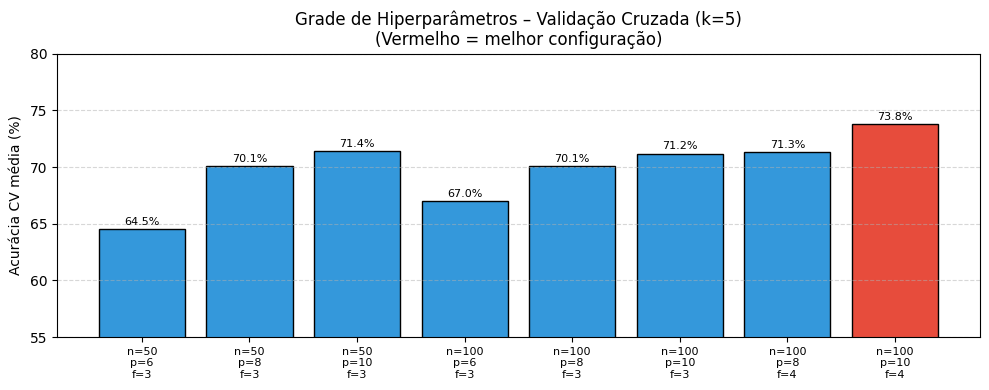

In [17]:
labels_cv = [f'n={r[0]}\np={r[1]}\nf={r[2]}' for r in resultados_cv]
accs_cv   = [r[3] * 100 for r in resultados_cv]
cores_cv  = ['#e74c3c' if r[3] == melhor_acc_cv else '#3498db' for r in resultados_cv]

plt.figure(figsize=(10, 4))
barras = plt.bar(range(len(labels_cv)), accs_cv, color=cores_cv, edgecolor='black')
plt.xticks(range(len(labels_cv)), labels_cv, fontsize=8)
plt.ylim(55, 80)
plt.ylabel('Acurácia CV média (%)')
plt.title('Grade de Hiperparâmetros – Validação Cruzada (k=5)\n'
          '(Vermelho = melhor configuração)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
for barra, acc in zip(barras, accs_cv):
    plt.annotate(f'{acc:.1f}%',
                 xy=(barra.get_x() + barra.get_width()/2, acc),
                 xytext=(0, 3), textcoords='offset points',
                 ha='center', fontsize=8)
plt.tight_layout()
plt.show()


Importância das features (posições do tabuleiro):
  Pos[0,0]: 10.80% █████████████████████
  Pos[0,1]: 11.41% ██████████████████████
  Pos[0,2]: 11.35% ██████████████████████
  Pos[1,0]: 12.02% ████████████████████████
  Pos[1,1]:  9.39% ██████████████████
  Pos[1,2]: 11.83% ███████████████████████
  Pos[2,0]: 11.17% ██████████████████████
  Pos[2,1]: 11.46% ██████████████████████
  Pos[2,2]: 10.57% █████████████████████


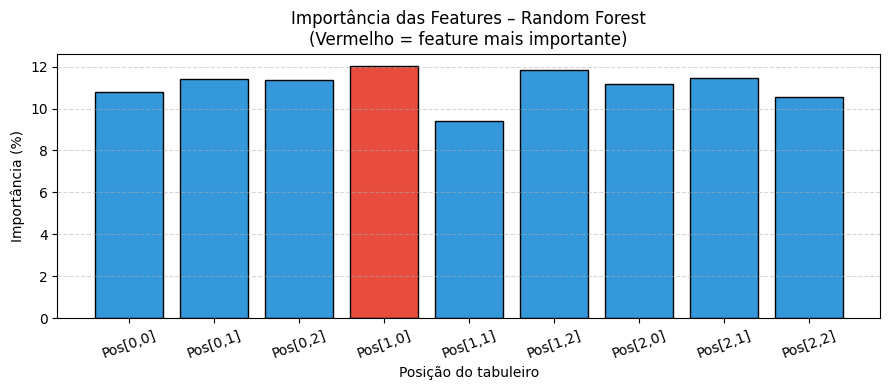

In [18]:
def conta_usos_features(no, contagem, n_feats):
    """Percorre a árvore contando quantas vezes cada feature é usada como critério."""
    if not isinstance(no, dict):
        return
    contagem[no['feat']] += 1
    conta_usos_features(no['esq'], contagem, n_feats)
    conta_usos_features(no['dir'], contagem, n_feats)

# Somar usos de todas as árvores
contagem_total = [0] * 9
for arvore in floresta:
    conta_usos_features(arvore, contagem_total, 9)

total_usos  = sum(contagem_total)
importancia = [c / total_usos for c in contagem_total]

# Nomes das posições do tabuleiro 3x3
NOMES_POS = [
    'Pos[0,0]', 'Pos[0,1]', 'Pos[0,2]',
    'Pos[1,0]', 'Pos[1,1]', 'Pos[1,2]',
    'Pos[2,0]', 'Pos[2,1]', 'Pos[2,2]'
]

print('Importância das features (posições do tabuleiro):')
for i, (nome, imp) in enumerate(zip(NOMES_POS, importancia)):
    barra = '█' * int(imp * 200)
    print(f'  {nome}: {imp*100:5.2f}% {barra}')

# Gráfico
plt.figure(figsize=(9, 4))
cores_imp = ['#e74c3c' if imp == max(importancia) else '#3498db' for imp in importancia]
plt.bar(NOMES_POS, [i*100 for i in importancia], color=cores_imp, edgecolor='black')
plt.xlabel('Posição do tabuleiro')
plt.ylabel('Importância (%)')
plt.title('Importância das Features – Random Forest\n'
          '(Vermelho = feature mais importante)')
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


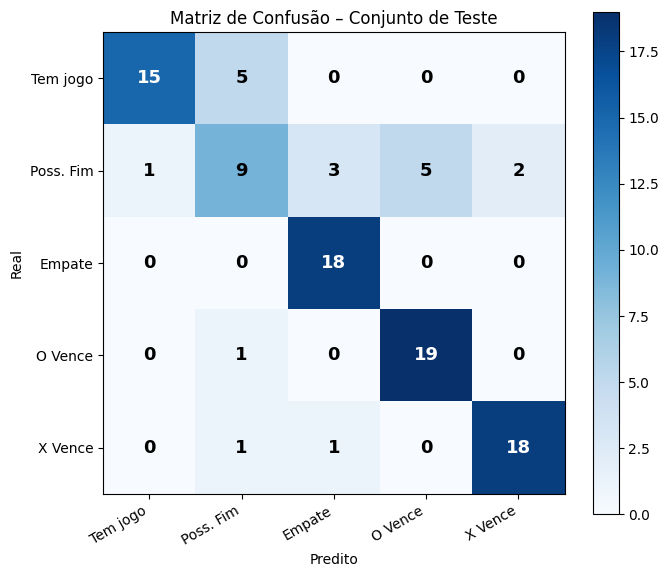

Matriz de confusão (linhas=real, colunas=predito):
[[15  5  0  0  0]
 [ 1  9  3  5  2]
 [ 0  0 18  0  0]
 [ 0  1  0 19  0]
 [ 0  1  1  0 18]]


In [19]:
# Cálculo manual da matriz de confusão
matriz_conf = [[0]*N_CLASSES for _ in range(N_CLASSES)]
for real, prev in zip(y_teste, pred_teste):
    matriz_conf[real][prev] += 1

# Visualização
import numpy as np
mat = np.array(matriz_conf)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(mat, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(N_CLASSES))
ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(NOMES_CURTOS, rotation=30, ha='right')
ax.set_yticklabels(NOMES_CURTOS)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão – Conjunto de Teste')

for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        cor = 'white' if mat[i,j] > mat.max()/2 else 'black'
        ax.text(j, i, str(mat[i,j]), ha='center', va='center',
                color=cor, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('Matriz de confusão (linhas=real, colunas=predito):')
print(mat)


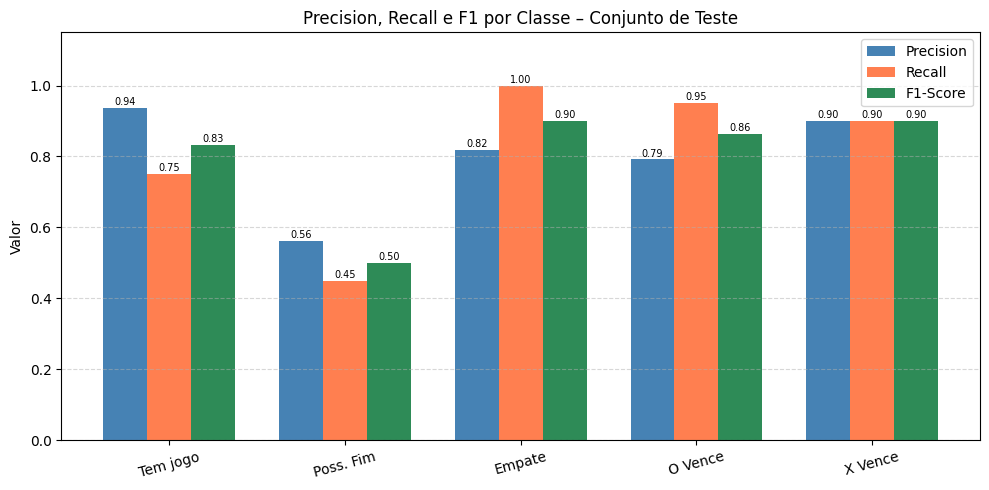

In [20]:
import numpy as np
x_pos   = np.arange(N_CLASSES)
largura = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x_pos - largura, prec_te, largura, label='Precision', color='steelblue')
b2 = ax.bar(x_pos,           rec_te,  largura, label='Recall',    color='coral')
b3 = ax.bar(x_pos + largura, f1_te,   largura, label='F1-Score',  color='seagreen')

ax.set_xticks(x_pos)
ax.set_xticklabels(NOMES_CURTOS, rotation=15)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Valor')
ax.set_title('Precision, Recall e F1 por Classe – Conjunto de Teste')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

for barras in [b1, b2, b3]:
    for barra in barras:
        h = barra.get_height()
        ax.annotate(f'{h:.2f}',
                    xy=(barra.get_x() + barra.get_width()/2, h),
                    xytext=(0, 2), textcoords='offset points',
                    ha='center', fontsize=7)

plt.tight_layout()
plt.show()


  20/100 árvores treinadas...
  40/100 árvores treinadas...
  60/100 árvores treinadas...
  80/100 árvores treinadas...
  100/100 árvores treinadas...


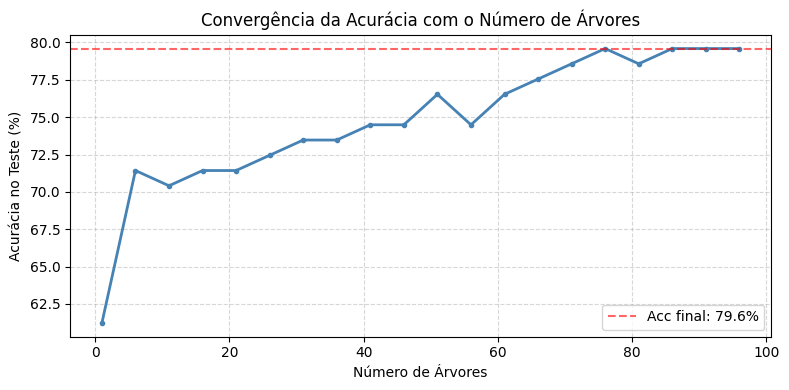

In [21]:
random.seed(42)
floresta_acum = treina_random_forest(X_treino, y_treino,
                                     N_ARVORES, PROF_MAX, MIN_AMOSTRAS, N_FEATURES)

pontos = list(range(1, N_ARVORES + 1, 5))   # avaliar a cada 5 árvores
accs_conv = []
for k in pontos:
    sub_floresta = floresta_acum[:k]
    preds_k = [prediz_random_forest(sub_floresta, x) for x in X_teste]
    accs_conv.append(sum(p==t for p,t in zip(preds_k,y_teste)) / len(y_teste) * 100)

plt.figure(figsize=(8, 4))
plt.plot(pontos, accs_conv, color='steelblue', linewidth=2, marker='o', markersize=3)
plt.axhline(y=accs_conv[-1], color='red', linestyle='--', alpha=0.6,
            label=f'Acc final: {accs_conv[-1]:.1f}%')
plt.xlabel('Número de Árvores')
plt.ylabel('Acurácia no Teste (%)')
plt.title('Convergência da Acurácia com o Número de Árvores')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
